# Create file with $\langle SSHA \rangle_t$ 

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da

import matplotlib.pyplot as plt

import os
from glob import glob
from swot import browse_swot_250m, browse_swot_2km, add_grid_metrics,rotate_ggd
from cstes import swot_dir_2km, zarr_dir, version_swot

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

______________
# Functions

In [2]:
dfs = browse_swot_2km().reset_index()
df3 = dfs[dfs.pass_number==3]
df16 = dfs[dfs.pass_number==16]

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [3]:
def prepared_concat(ds):
    cn = ds.cycle_number.mean().values
    ds =ds.drop_vars('cycle_number')
    ds['cycle_number']=('cycle_number', [cn])
    return ds
#ds = xr.open_mfdataset(df.file.values, preprocess=prepared_concat)

In [4]:
ds3 = xr.open_mfdataset(df3.file.values, preprocess=prepared_concat)[['duacs_ssha_karin_2_filtered', 'duacs_ssha_karin_2_calibrated', 'duacs_editing_flag']]
ds16 = xr.open_mfdataset(df16.file.values, preprocess=prepared_concat)[['duacs_ssha_karin_2_filtered', 'duacs_ssha_karin_2_calibrated', 'duacs_editing_flag']]
if version_swot == '2.0.1' : ds3['time'] = (ds3.time - np.timedelta64(946684800000000000, 'ns'))
if version_swot == '2.0.1' : ds16['time'] = (ds16.time - np.timedelta64(946684800000000000, 'ns'))

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

In [14]:
ds3.time.compute()

<xarray.DataArray 'time' (cycle_number: 97, num_lines: 496)> Size: 385kB
array([['2023-03-29T00:20:02.129161984', '2023-03-29T00:20:02.438726528',
        '2023-03-29T00:20:02.748924544', ...,
        '2023-03-29T00:22:35.166311168', '2023-03-29T00:22:35.472964608',
        '2023-03-29T00:22:35.781814144'],
       ['2023-03-30T00:10:40.034470400', '2023-03-30T00:10:40.344218112',
        '2023-03-30T00:10:40.653767680', ...,
        '2023-03-30T00:13:13.055305472', '2023-03-30T00:13:13.370546048',
        '2023-03-30T00:13:13.688545408'],
       ['2023-03-31T00:01:16.978825600', '2023-03-31T00:01:17.289108864',
        '2023-03-31T00:01:17.599441536', ...,
        '2023-03-31T00:03:50.003920768', '2023-03-31T00:03:50.313357312',
        '2023-03-31T00:03:50.624167168'],
       ...,
       ['2023-07-08T08:24:23.738086400', '2023-07-08T08:24:24.048411904',
        '2023-07-08T08:24:24.358675968', ...,
        '2023-07-08T08:26:56.743106304', '2023-07-08T08:26:57.053545088',
        '2023-07-08T08:26:57.363931264'],
       ['2023-07-09T08:15:01.591355776', '2023-07-09T08:15:01.901602176',
        '2023-07-09T08:15:02.211936128', ...,
        '2023-07-09T08:17:34.592066304', '2023-07-09T08:17:34.901944576',
        '2023-07-09T08:17:35.212668032'],
       ['2023-07-10T08:05:39.421883904', '2023-07-10T08:05:39.732142592',
        '2023-07-10T08:05:40.042497536', ...,
        '2023-07-10T08:08:12.426618112', '2023-07-10T08:08:12.737054208',
        '2023-07-10T08:08:13.047433856']], dtype='datetime64[ns]')
Coordinates:
    latitude_nadir   (cycle_number, num_lines) float64 385kB 35.03 ... 43.72
    longitude_nadir  (cycle_number, num_lines) float64 385kB 2.997 ... 5.592
    time             (cycle_number, num_lines) datetime64[ns] 385kB 2023-03-2...
  * cycle_number     (cycle_number) float64 776B 474.0 475.0 ... 577.0 578.0
Dimensions without coordinates: num_lines

In [5]:
ds3m = ds3.rename({'duacs_ssha_karin_2_filtered':'mean_sshaf','duacs_ssha_karin_2_calibrated':'mean_sshac' }).mean('cycle_number').compute()
ds16m = ds16.rename({'duacs_ssha_karin_2_filtered':'mean_sshaf','duacs_ssha_karin_2_calibrated':'mean_sshac' }).mean('cycle_number').compute()

In [6]:
ds3m.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot2km', f'pass3_swot2km_meanssha.nc'))
ds16m.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot2km', f'pass16_swot2km_meanssha.nc'))

In [5]:
ds3m = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot2km', f'pass3_swot2km_meanssha.nc'))
ds16m = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot2km', f'pass16_swot2km_meanssha.nc'))

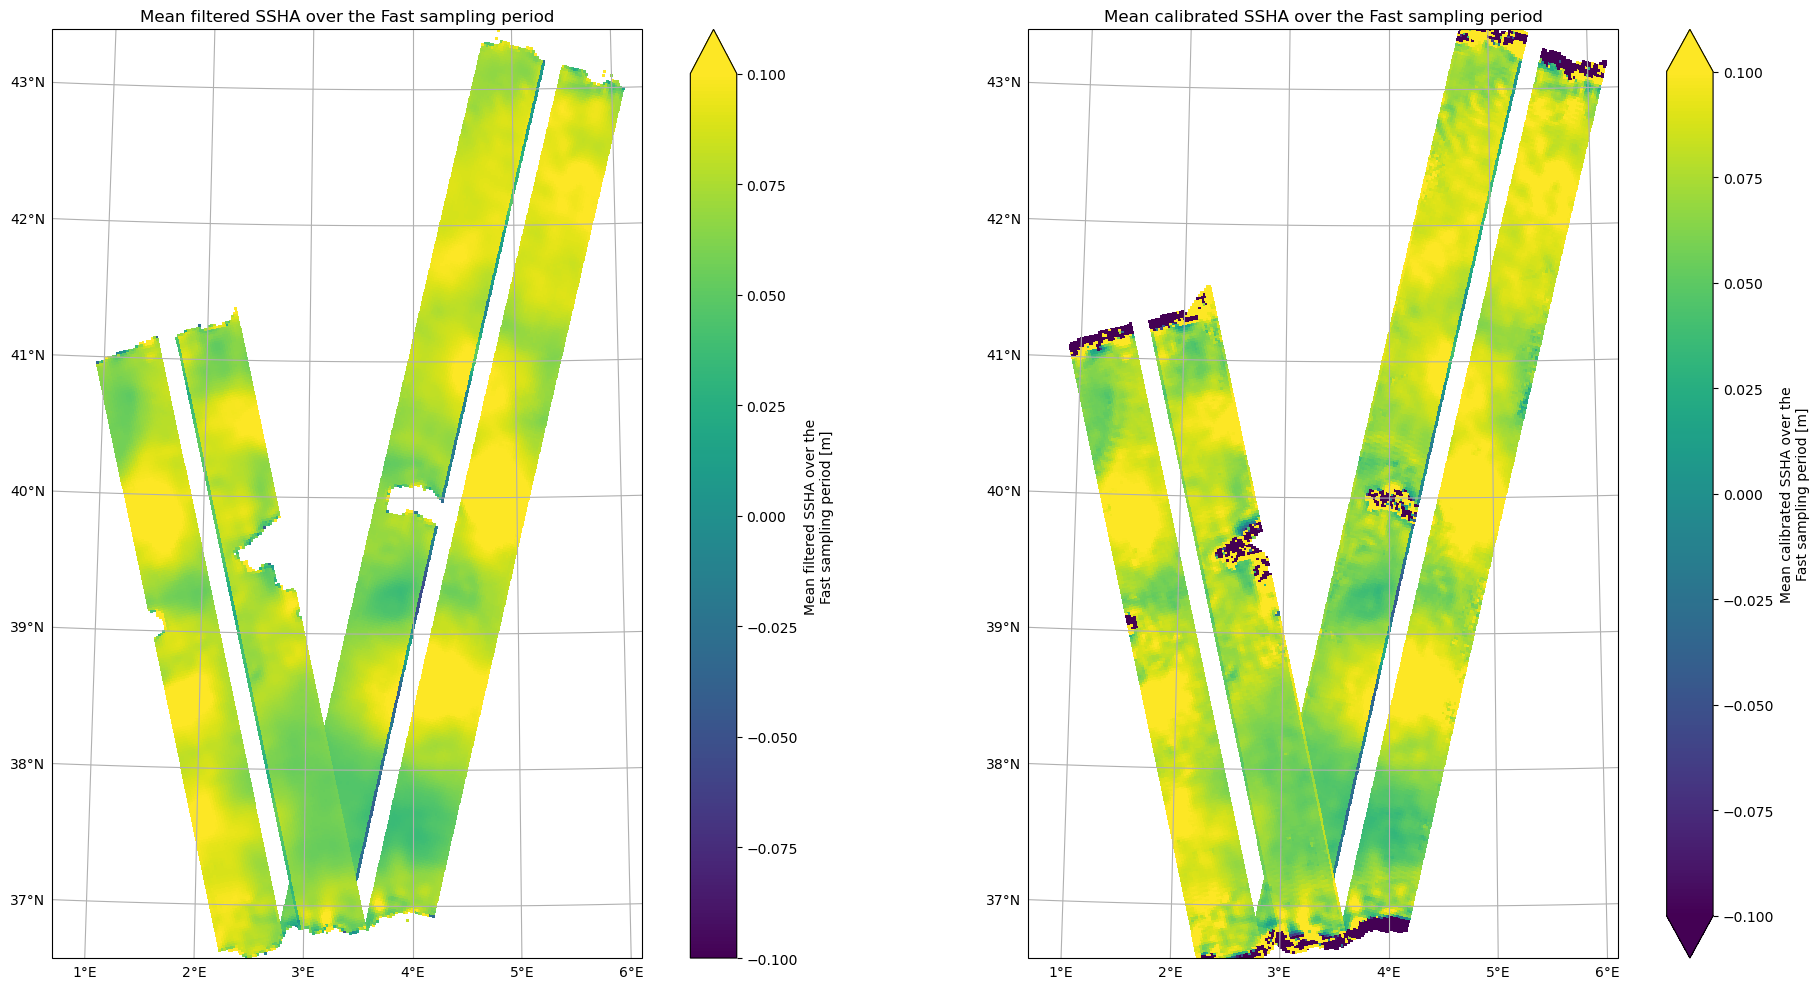

In [6]:
for ds in [ds3m, ds16m]:
    ds['mean_sshaf'] = ds['mean_sshaf'].assign_attrs({'long_name' :'Mean filtered SSHA over the Fast sampling period', 'units':'m'})
    ds['mean_sshac'] = ds['mean_sshac'].assign_attrs({'long_name' :'Mean calibrated SSHA over the Fast sampling period', 'units':'m'})


bbox = [0.7, 6.1, 36.6, 43.4]

fig = plt.figure(figsize=(20,10), frameon =False)
vmin, vmax = -0.1, 0.1

ax = fig.add_subplot(1,2,1, projection=ccrs.Orthographic(4,40))
ds3m.mean_sshaf.plot(x='longitude', y='latitude',ax=ax, transform=crs, vmin=vmin, vmax=vmax)
ds16m.mean_sshaf.plot(x='longitude', y='latitude',ax=ax, transform=crs, add_colorbar=False, vmin=vmin, vmax=vmax)
ax.set_title(f'Mean filtered SSHA over the Fast sampling period')
gl = ax.gridlines(draw_labels=True,)
ax.set_extent(bbox)
gl.top_labels = False
gl.right_labels = False


ax = fig.add_subplot(1,2,2, projection=ccrs.Orthographic(4,40))
ds3m.mean_sshac.plot(x='longitude', y='latitude',ax=ax, transform=crs, vmin=vmin, vmax=vmax)
ds16m.mean_sshac.plot(x='longitude', y='latitude',ax=ax, transform=crs, add_colorbar=False, vmin=vmin, vmax=vmax)
ax.set_title(f'Mean calibrated SSHA over the Fast sampling period')
gl = ax.gridlines(draw_labels=True,)
ax.set_extent(bbox)
gl.top_labels = False
gl.right_labels = False


fig.tight_layout()

In [62]:
product = 'swot2km'
method = 'diff_only'

pass_=3
path3 = os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, method, f'pass3_{product}_{method}.nc')
path16 = os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, method, f'pass16_{product}_{method}.nc')
ds3m = xr.open_dataset(path3).sel(cycle_number=500)
ds16m = xr.open_dataset(path16).sel(cycle_number=500)

dss3 = xr.open_dataset(dfs.where((dfs.pass_number==3)&(dfs.cycle_number==500)).dropna().file.values[0])
ds3m['phi'] = dss3.phi
dss16 = xr.open_dataset(dfs.where((dfs.pass_number==16)&(dfs.cycle_number==500)).dropna().file.values[0])
ds16m['phi'] = dss16.phi

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


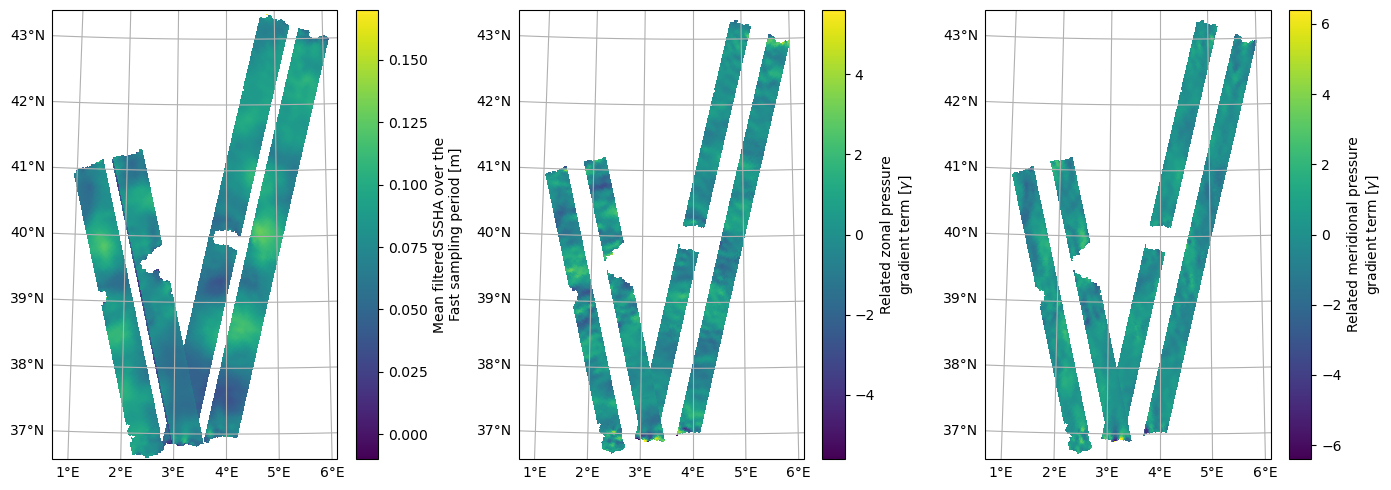

In [70]:
from swot import rotate
from cstes import U
g=9.81
for ds in [ds3m, ds16m]:
    
    ds['sshafm'] = (ds.etaf-ds.etafm).assign_attrs({'long_name' :'Mean filtered SSHA over the Fast sampling period', 'units':'m'})
    ds['sshacm'] = (ds.etac-ds.etacm).assign_attrs({'long_name' :'Mean calibrated SSHA over the Fast sampling period', 'units':'m'})
    ds['dx_sshafm'] = (ds.dx_etaf-ds.dx_etafm)#.assign_attrs({'long_name' :'Zonal gradient Mean filtered SSHA over the Fast sampling period', 'units':'m'})
    ds['dx_sshacm'] = (ds.dx_etac-ds.dx_etacm)
    ds['dy_sshafm'] = (ds.dy_etaf-ds.dy_etafm)#.assign_attrs({'long_name' :'Zonal gradient Mean filtered SSHA over the Fast sampling period', 'units':'m'})
    ds['dy_sshacm'] = (ds.dy_etac-ds.dy_etacm)
    
    ds['ggde_sshafm'] = (g*rotate(ds.dx_sshafm, ds.dy_sshafm, ds.phi)[0]/U).assign_attrs({'long_name' :'Related zonal pressure gradient term', 'units':r'$\gamma$'})
    ds['ggdn_sshafm'] = (g*rotate(ds.dx_sshafm, ds.dy_sshafm, ds.phi)[1]/U).assign_attrs({'long_name' :'Related meridional pressure gradient term', 'units':r'$\gamma$'})

bbox = [0.7, 6.1, 36.6, 43.4]

fig = plt.figure(figsize=(14,5), frameon =False)
kwargs = dict( cmap='viridis', vmin=-0.01, vmax=0.17)
ax = fig.add_subplot(1,3,1, projection=ccrs.Orthographic(4,40))
ds3m.sshafm.plot(x='longitude', y='latitude',ax=ax, transform=crs,**kwargs)
ds16m.sshafm.plot(x='longitude', y='latitude',ax=ax, transform=crs, add_colorbar=False, **kwargs)
#ax.set_title(f'Mean filtered SSHA over the Fast sampling period')
gl = ax.gridlines(draw_labels=True,)
ax.set_extent(bbox)
gl.top_labels = False
gl.right_labels = False
ax.set_title('')

ax = fig.add_subplot(1,3,2, projection=ccrs.Orthographic(4,40))
kwargs = dict( cmap='viridis')#, vmin=-0.01, vmax=0.17)
ds3m.ggde_sshafm.plot(x='longitude', y='latitude',ax=ax, transform=crs,**kwargs)
ds16m.ggde_sshafm.plot(x='longitude', y='latitude',ax=ax, transform=crs, add_colorbar=False, **kwargs)
#ax.set_title(f'Mean filtered SSHA over the Fast sampling period')
gl = ax.gridlines(draw_labels=True,)
ax.set_extent(bbox)
gl.top_labels = False
gl.right_labels = False
ax.set_title('')

ax = fig.add_subplot(1,3,3, projection=ccrs.Orthographic(4,40))
kwargs = dict( cmap='viridis')#, vmin=-0.01, vmax=0.17)
ds3m.ggdn_sshafm.plot(x='longitude', y='latitude',ax=ax, transform=crs,**kwargs)
ds16m.ggdn_sshafm.plot(x='longitude', y='latitude',ax=ax, transform=crs, add_colorbar=False, **kwargs)
#ax.set_title(f'Mean filtered SSHA over the Fast sampling period')
gl = ax.gridlines(draw_labels=True,)
ax.set_extent(bbox)
gl.top_labels = False
gl.right_labels = False
ax.set_title('')


fig.tight_layout()


In [47]:
dss3 = xr.open_dataset(dfs.where((dfs.pass_number==3)&(dfs.cycle_number==500)).dropna().file.values[0])
ds3m['phi'] = dss3.phi
dss16 = xr.open_dataset(dfs.where((dfs.pass_number==16)&(dfs.cycle_number==500)).dropna().file.values[0])
ds16m['phi'] = dss16.phi

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


In [49]:
dss3.phi

76.96918844368692